# Experiment No. 2 — Data Filtering, Transformation and Preprocessing

**Aim:** To perform data filtering, transformation, and preprocessing for better visualization.

**Dataset:** 12000 Data Science Jobs in India (Naukri.com): https://www.kaggle.com/datasets/anandhuh/data-science-jobs-in-india
Each row is one job posting with its title, company, location, experience required and skills.

*Theory and detailed explanations are in the experiment report (Word document).*

## Step 1 — Load and Inspect the Dataset

In [ ]:
# Import the required libraries
import os                          # to build file paths
import pandas as pd                # to load and handle the data table
import matplotlib.pyplot as plt    # to draw charts
import seaborn as sns              # to draw statistical charts easily

# Use a white background with grid lines for all charts
sns.set_theme(style='whitegrid')

Run **only one** of the next two cells: Option 1 on a laptop, Option 2 on Google Colab.

In [2]:
# OPTION 1 - Running on laptop (CSV file is in the same folder as this notebook)
path = '.'    # '.' means the current folder

In [3]:
# OPTION 2 - Running on Google Colab (download the dataset from Kaggle)
# Remove the # from the two lines below when using Colab.

# import kagglehub
# path = kagglehub.dataset_download('anandhuh/data-science-jobs-in-india')

In [4]:
# Read the CSV file into a pandas DataFrame (table)
df = pd.read_csv(os.path.join(path, 'naukri_data_science_jobs_india.csv'))

# shape gives (number of rows, number of columns)
print('Dataset shape:', df.shape)

# Show the first 5 rows
df.head()

Dataset shape: (12000, 5)


,Job_Role,Company,Location,Job Experience,Skills/Description
0,Senior Data Scientist,UPL,"Bangalore/Bengaluru, Mumbai (All Areas)",3-6,"python, MLT, statistical modeling, machine lea..."
1,Senior Data Scientist,Walmart,Bangalore/Bengaluru,5-9,"Data Science, Machine learning, Python, Azure,..."
2,Applied Data Scientist / ML Senior Engineer (P...,SAP India Pvt.Ltd,Bangalore/Bengaluru,5-10,"Python, IT Skills, Testing, Cloud, Product Man..."
3,Data Scientist,UPL,"Bangalore/Bengaluru, Mumbai (All Areas)",1-4,"python, machine learning, Data Science, data a..."
4,Data Scientist,Walmart,Bangalore/Bengaluru,4-8,"IT Skills, Python, Data Science, Machine Learn..."


In [5]:
# Column names, number of filled values, and data type of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Job_Role            12000 non-null  object
 1   Company             12000 non-null  object
 2   Location            12000 non-null  object
 3   Job Experience      12000 non-null  object
 4   Skills/Description  12000 non-null  object
dtypes: object(5)
memory usage: 468.9+ KB


In [6]:
# Count missing values and duplicate rows
print('Missing values in each column:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())

Missing values in each column:
Job_Role              0
Company               0
Location              0
Job Experience        0
Skills/Description    0
dtype: int64

Duplicate rows: 0


**Observation:** 12,000 job postings and 5 columns, all stored as text. There are no empty cells and no exact duplicate rows, but some values are wrong (handled in Step 2).

## Step 2 — Handle Missing or Unwanted Data

In [7]:
# Rename columns to short, simple names without spaces or slashes
df = df.rename(columns={
    'Job_Role': 'Job_Title',
    'Job Experience': 'Experience',
    'Skills/Description': 'Skills'
})
df.columns

Index(['Job_Title', 'Company', 'Location', 'Experience', 'Skills'], dtype='object')

In [8]:
# Valid experience values look like '3-6' (number - number)
# str.match() returns True for values that follow this pattern
valid = df['Experience'].str.match(r'^\d+-\d+$')

# Show the values that are NOT valid experience
print('Invalid experience values:', (~valid).sum())
df.loc[~valid, ['Job_Title', 'Experience']]

Invalid experience values: 7


,Job_Title,Experience
1847,Data Analyst,12 May - 21 May
2171,Lead Data Engineer,B.Tech/B.E.
3029,MIS Data Analyst,16 May - 22 May
7150,Azure Data Engineer-Pune,18 May
8681,Python / Java /.Net /PHP/Web Developer/Android...,12 May - 21 May
9535,Software Trainee engineer,17 May - 26 May
10498,Virtual Walk-in - Freshers - SQL/Python - 09th...,18 May


In [9]:
# Mark the invalid values as missing (NaN)
df.loc[~valid, 'Experience'] = None
print('Missing experience values now:', df['Experience'].isnull().sum())

# Only a handful of rows are affected, and we cannot guess their experience,
# so these rows are removed with dropna()
df = df.dropna(subset=['Experience'])
print('Rows left:', len(df))

Missing experience values now: 7
Rows left: 11993


In [10]:
# Find duplicates that differ only in capital letters or extra spaces
# Make a lower-case, space-trimmed copy only for comparing
compare = df.apply(lambda col: col.str.lower().str.strip())
print('Duplicate rows (ignoring case and spaces):', compare.duplicated().sum())

# Keep only the rows that are not duplicates
df = df[~compare.duplicated()]
print('Rows left:', len(df))

Duplicate rows (ignoring case and spaces): 2
Rows left: 11991


**Observation:** 7 jobs had a date or a degree (e.g. "12 May - 21 May", "B.Tech/B.E.") instead of years of experience. They were marked as missing and removed. 2 more rows were duplicates that differed only in capital letters or spaces. **11,991 rows** are left.

## Step 3 — Transform Data into a Suitable Format

In [11]:
# Split experience '3-6' into two number columns: minimum and maximum years
exp_parts = df['Experience'].str.split('-', expand=True)   # gives two columns: '3' and '6'
df['Min_Exp'] = exp_parts[0].astype(int)                    # convert text to number
df['Max_Exp'] = exp_parts[1].astype(int)

df[['Experience', 'Min_Exp', 'Max_Exp']].head()

,Experience,Min_Exp,Max_Exp
0,3-6,3,6
1,5-9,5,9
2,5-10,5,10
3,1-4,1,4
4,4-8,4,8


In [12]:
# The same city is written in different ways - map each spelling to one standard name
city_names = {
    'Bangalore/Bengaluru': 'Bengaluru', 'Bangalore': 'Bengaluru',
    'Hyderabad/Secunderabad': 'Hyderabad', 'Secunderabad': 'Hyderabad',
    'Mumbai (All Areas)': 'Mumbai', 'Navi Mumbai': 'Mumbai', 'Mumbai Suburban': 'Mumbai', 'Thane': 'Mumbai',
    'Gurgaon/Gurugram': 'Gurugram', 'Gurgaon': 'Gurugram',
    'Delhi / NCR': 'Delhi NCR', 'New Delhi': 'Delhi NCR', 'Delhi': 'Delhi NCR',
    'Kochi/Cochin': 'Kochi', 'Trivandrum/Thiruvananthapuram': 'Thiruvananthapuram',
}

def clean_cities(text):
    # One job can list several cities separated by commas
    cities = [c.strip() for c in text.split(',')]
    # Replace each spelling with its standard name (keep it unchanged if not in the dictionary)
    return [city_names.get(c, c) for c in cities]

df['City_List'] = df['Location'].apply(clean_cities)
df[['Location', 'City_List']].head()

,Location,City_List
0,"Bangalore/Bengaluru, Mumbai (All Areas)","[Bengaluru, Mumbai]"
1,Bangalore/Bengaluru,[Bengaluru]
2,Bangalore/Bengaluru,[Bengaluru]
3,"Bangalore/Bengaluru, Mumbai (All Areas)","[Bengaluru, Mumbai]"
4,Bangalore/Bengaluru,[Bengaluru]


In [13]:
# Convert the skills text into a clean list: lower case, no extra spaces
df['Skill_List'] = df['Skills'].str.lower().str.split(',')
df['Skill_List'] = df['Skill_List'].apply(lambda skills: [s.strip() for s in skills])

# 'it skills' is a general tag added by the job site, not a real skill, so remove it
df['Skill_List'] = df['Skill_List'].apply(lambda skills: [s for s in skills if s != 'it skills'])

df[['Skills', 'Skill_List']].head()

,Skills,Skill_List
0,"python, MLT, statistical modeling, machine lea...","[python, mlt, statistical modeling, machine le..."
1,"Data Science, Machine learning, Python, Azure,...","[data science, machine learning, python, azure..."
2,"Python, IT Skills, Testing, Cloud, Product Man...","[python, testing, cloud, product management, s..."
3,"python, machine learning, Data Science, data a...","[python, machine learning, data science, data ..."
4,"IT Skills, Python, Data Science, Machine Learn...","[python, data science, machine learning, big d..."


**Observation:** Experience is now two number columns. Different spellings of the same city (e.g. "Bangalore/Bengaluru" and "Bengaluru") now have one name. Skills are a clean list, without the general "it skills" tag.

## Step 4 — Create New / Derived Columns

In [14]:
# Average experience = middle of the min-max range
df['Avg_Exp'] = (df['Min_Exp'] + df['Max_Exp']) / 2

# Experience level: group the minimum experience into ranges (binning)
df['Experience_Level'] = pd.cut(
    df['Min_Exp'],
    bins=[-1, 1, 3, 6, 100],                                  # 0-1, 2-3, 4-6, 7+
    labels=['Fresher (0-1)', 'Junior (2-3)', 'Mid (4-6)', 'Senior (7+)']
)

df[['Experience', 'Min_Exp', 'Avg_Exp', 'Experience_Level']].head()

,Experience,Min_Exp,Avg_Exp,Experience_Level
0,3-6,3,4.5,Junior (2-3)
1,5-9,5,7.0,Mid (4-6)
2,5-10,5,7.5,Mid (4-6)
3,1-4,1,2.5,Fresher (0-1)
4,4-8,4,6.0,Mid (4-6)


In [15]:
# Role: group thousands of job titles into a few simple roles using keywords
def find_role(title):
    t = title.lower()
    words = t.replace('/', ' ').replace('-', ' ').replace('(', ' ').replace(')', ' ').split()   # separate words
    if 'data engineer' in t or 'big data' in t or 'etl' in t or 'data architect' in t:
        return 'Data Engineer'
    if 'data scien' in t or 'applied scientist' in t:
        return 'Data Scientist'
    if 'machine learning' in t or 'deep learning' in t or 'nlp' in t or 'ml' in words or 'ai' in words:
        return 'ML / AI Engineer'
    if 'analyst' in t or 'analytics' in t:
        return 'Data / Business Analyst'
    if 'developer' in t or 'software' in t or 'full-stack' in t or 'full stack' in t or 'devops' in t:
        return 'Software Developer'
    return 'Other'

df['Role'] = df['Job_Title'].apply(find_role)
df[['Job_Title', 'Role']].head(8)

,Job_Title,Role
0,Senior Data Scientist,Data Scientist
1,Senior Data Scientist,Data Scientist
2,Applied Data Scientist / ML Senior Engineer (P...,Data Scientist
3,Data Scientist,Data Scientist
4,Data Scientist,Data Scientist
5,Principal Data Scientist,Data Scientist
6,Data Scientist,Data Scientist
7,Expert Data Scientist,Data Scientist


In [16]:
# Main city = the first city listed for the job
df['Main_City'] = df['City_List'].str[0]

# Number of skills asked for in each job
df['Skill_Count'] = df['Skill_List'].str.len()

# True / False columns: does the job ask for this skill?
for skill in ['python', 'sql', 'machine learning', 'excel', 'power bi', 'tableau', 'aws']:
    column_name = 'Needs_' + skill.title().replace(' ', '_')       # e.g. 'power bi' -> 'Needs_Power_Bi'
    df[column_name] = df['Skill_List'].apply(lambda skills: skill in skills)

df[['Main_City', 'Skill_Count', 'Needs_Python', 'Needs_Sql', 'Needs_Excel']].head()

,Main_City,Skill_Count,Needs_Python,Needs_Sql,Needs_Excel
0,Bengaluru,7,True,False,False
1,Bengaluru,8,True,False,False
2,Bengaluru,7,True,False,False
3,Bengaluru,6,True,False,False
4,Bengaluru,7,True,False,False


**Observation:** New columns: `Avg_Exp`, `Experience_Level` (made by binning), `Role` (thousands of job titles grouped into 6 roles), `Main_City`, `Skill_Count`, and True/False `Needs_...` columns for important skills.

## Step 5 — Select Required Rows and Columns

In [17]:
# loc[] - select columns by NAME (keep only the columns needed for analysis)
jobs = df.loc[:, ['Job_Title', 'Company', 'Role', 'Main_City', 'Min_Exp', 'Max_Exp',
                  'Experience_Level', 'Skill_Count', 'Needs_Python', 'Needs_Sql']]
jobs.head()

,Job_Title,Company,Role,Main_City,Min_Exp,Max_Exp,Experience_Level,Skill_Count,Needs_Python,Needs_Sql
0,Senior Data Scientist,UPL,Data Scientist,Bengaluru,3,6,Junior (2-3),7,True,False
1,Senior Data Scientist,Walmart,Data Scientist,Bengaluru,5,9,Mid (4-6),8,True,False
2,Applied Data Scientist / ML Senior Engineer (P...,SAP India Pvt.Ltd,Data Scientist,Bengaluru,5,10,Mid (4-6),7,True,False
3,Data Scientist,UPL,Data Scientist,Bengaluru,1,4,Fresher (0-1),6,True,False
4,Data Scientist,Walmart,Data Scientist,Bengaluru,4,8,Mid (4-6),7,True,False


In [ ]:
# iloc[] - select rows and columns by POSITION
# rows 0 to 4, first 3 columns
jobs.iloc[0:5, 0:3]

,Job_Title,Company,Role
0,Senior Data Scientist,UPL,Data Scientist
1,Senior Data Scientist,Walmart,Data Scientist
2,Applied Data Scientist / ML Senior Engineer (P...,SAP India Pvt.Ltd,Data Scientist
3,Data Scientist,UPL,Data Scientist
4,Data Scientist,Walmart,Data Scientist


**Observation:** `loc[]` selects columns by their **names**, and `iloc[]` selects rows and columns by their **position** (numbers).

## Step 6 — Filter Data Based on Specific Conditions

In [19]:
# Filter 1: jobs open to freshers (minimum experience 0 or 1 year)
fresher_jobs = df[df['Min_Exp'] <= 1]
print('Fresher jobs:', len(fresher_jobs))
fresher_jobs[['Job_Title', 'Company', 'Main_City', 'Experience']].head()

Fresher jobs: 1480


,Job_Title,Company,Main_City,Experience
3,Data Scientist,UPL,Bengaluru,1-4
19,Data Scientist V,IGT India,Hyderabad,1-6
25,Junior Data Analyst/ Scientist- Fresher Position,Sejal Consulting Hub,Remote,0-3
48,Analyst - Applied Data Scientist,Tesco,Bengaluru,1-2
50,Freshers For Junior Data Scientist,Aaum Research and Analytics Private Limited,Chennai,0-1


In [20]:
# Filter 2: jobs in Mumbai (Mumbai can appear anywhere in the list of cities)
mumbai_jobs = df[df['City_List'].apply(lambda cities: 'Mumbai' in cities)]
print('Jobs in Mumbai:', len(mumbai_jobs))

Jobs in Mumbai: 1480


In [21]:
# Filter 3: jobs that need BOTH Python AND SQL (& = and)
python_sql_jobs = df[df['Needs_Python'] & df['Needs_Sql']]
print('Jobs needing Python and SQL:', len(python_sql_jobs))

Jobs needing Python and SQL: 661


In [22]:
# Filter 4: Data / Business Analyst jobs in Mumbai or Pune, using isin()
analyst_jobs = df[(df['Role'] == 'Data / Business Analyst') & (df['Main_City'].isin(['Mumbai', 'Pune']))]
print('Analyst jobs in Mumbai or Pune:', len(analyst_jobs))

Analyst jobs in Mumbai or Pune: 927


In [ ]:
# Filter 5: the same kind of condition written with query() (SQL-like text)
mumbai_freshers = df.query("Main_City == 'Mumbai' and Min_Exp <= 1")
print('Fresher jobs with Mumbai as main city:', len(mumbai_freshers))
mumbai_freshers[['Job_Title', 'Company', 'Experience']].head()

Fresher jobs with Mumbai as main city: 216


,Job_Title,Company,Experience
258,Urgent Opening For Data Scientist For Big4 Com...,Orcapod Consulting Services Private Limited,1-6
281,Senior Data Scientist,Boston Consulting Group,1-2
501,Data Scientist,Teleperformance India,1-6
508,Data Scientist- Clinical Trial,Abbott,1-5
596,Junior Data Scientist/ta,WSD Consultant,1-5


**Observation:** 1,480 jobs are open to freshers, 661 jobs need both Python and SQL, 927 analyst jobs are mainly in Mumbai or Pune, and 216 fresher jobs are mainly in Mumbai. 1,480 jobs also list Mumbai. That matches the fresher count only by coincidence: they are different jobs, and just 245 are in both groups.

## Step 7 — Prepare the Transformed Dataset for Visualization

In [24]:
# Final clean dataset: only useful columns, sorted by minimum experience
final_df = df[['Job_Title', 'Role', 'Company', 'Main_City', 'Min_Exp', 'Max_Exp', 'Avg_Exp',
               'Experience_Level', 'Skill_Count', 'Needs_Python', 'Needs_Sql',
               'Needs_Machine_Learning', 'Needs_Excel', 'Needs_Power_Bi', 'Needs_Tableau', 'Needs_Aws']]
final_df = final_df.sort_values('Min_Exp')

# Save it as a new CSV file
final_df.to_csv('cleaned_ds_jobs_india.csv', index=False)
print('Final dataset shape:', final_df.shape)
final_df.head()

Final dataset shape: (11991, 16)


,Job_Title,Role,Company,Main_City,Min_Exp,Max_Exp,Avg_Exp,Experience_Level,Skill_Count,Needs_Python,Needs_Sql,Needs_Machine_Learning,Needs_Excel,Needs_Power_Bi,Needs_Tableau,Needs_Aws
5927,Junior Analyst (2022 Graduates) - Gamma,Data / Business Analyst,Boston Consulting Group,Gurugram,0,0,0.0,Fresher (0-1),8,True,True,False,False,False,False,False
2722,Data Engineering Lead,Data Engineer,Purpose PBC,Mumbai,0,1,0.5,Fresher (0-1),1,False,False,False,False,False,False,False
2714,Scientist I - Strain Engineering,Other,Perfect Day,Bengaluru,0,2,1.0,Fresher (0-1),8,False,False,False,False,False,False,False
2712,Fresher Job - Junior MIS Executive / Data Analyst,Data / Business Analyst,Z H Consultancy Services Private Ltd.,Kochi,0,1,0.5,Fresher (0-1),7,False,False,False,True,False,False,False
2657,Data Analyst & Business Analyst Fresher Experi...,Data / Business Analyst,Freelancer Varsha Abhijeet Kakde,Pune,0,2,1.0,Fresher (0-1),8,True,False,False,False,True,False,False


### Chart 1 — Jobs by City: Before vs After Cleaning

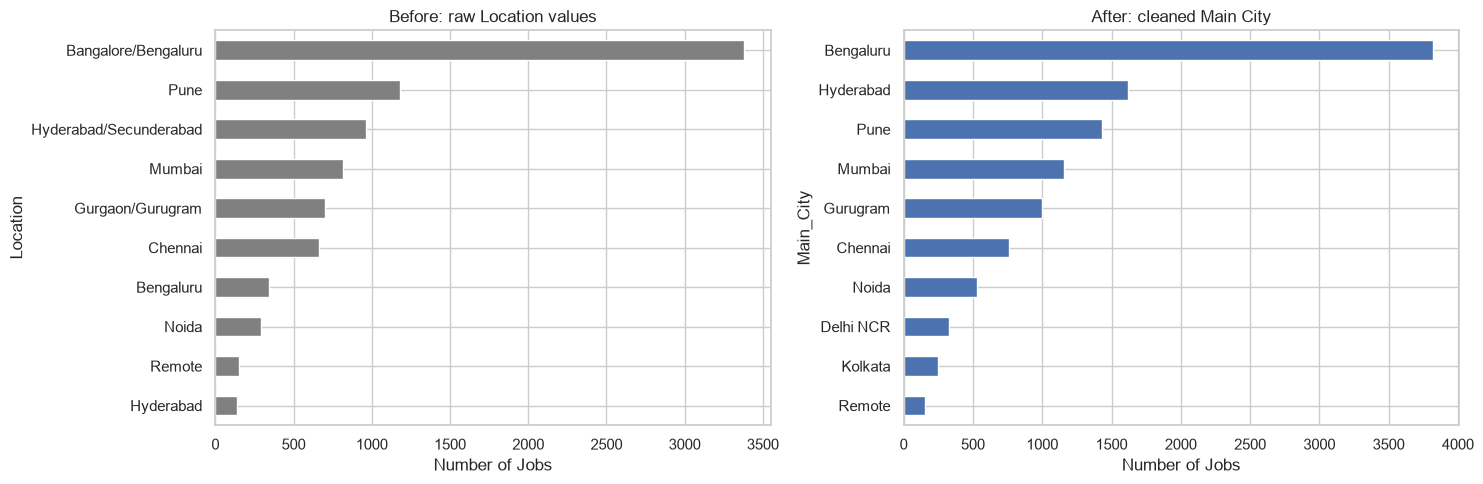

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# BEFORE: raw Location text (same city appears under different names)
df['Location'].value_counts().head(10).sort_values().plot(kind='barh', ax=axes[0], color='grey')
axes[0].set_title('Before: raw Location values')
axes[0].set_xlabel('Number of Jobs')

# AFTER: cleaned main city
df['Main_City'].value_counts().head(10).sort_values().plot(kind='barh', ax=axes[1])
axes[1].set_title('After: cleaned Main City')
axes[1].set_xlabel('Number of Jobs')

plt.tight_layout()
plt.show()

**Observation:** Before cleaning, Bengaluru appears twice ("Bangalore/Bengaluru" with 3,382 jobs and "Bengaluru" with 342), and so does Hyderabad, so their counts are split. After cleaning, **Bengaluru clearly leads with 3,818 jobs**, followed by Hyderabad (1,616), Pune (1,431) and Mumbai (1,155).

### Chart 2 — Top 15 Skills in Demand

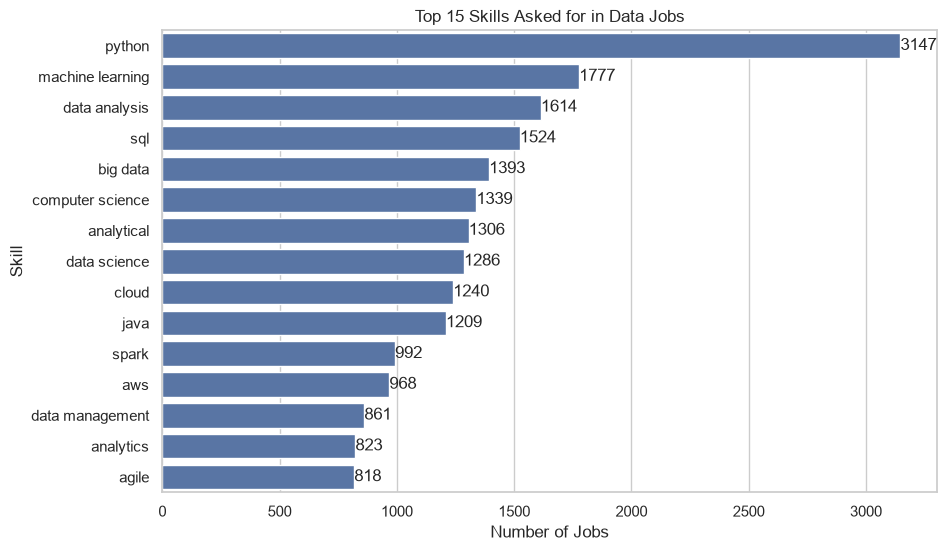

In [26]:
# explode() puts each skill of a job on its own row, so the skills can be counted
all_skills = df['Skill_List'].explode()
top_skills = all_skills.value_counts().head(15)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top_skills.values, y=top_skills.index)
ax.bar_label(ax.containers[0])          # write the count at the end of each bar
plt.title('Top 15 Skills Asked for in Data Jobs')
plt.xlabel('Number of Jobs')
plt.ylabel('Skill')
plt.show()

**Observation:** **Python is the most wanted skill (3,147 jobs)**, far ahead of machine learning (1,777), data analysis (1,614) and SQL (1,524). Cloud and big-data skills (cloud, Spark, AWS) are also common.

### Chart 3 — Jobs by Role

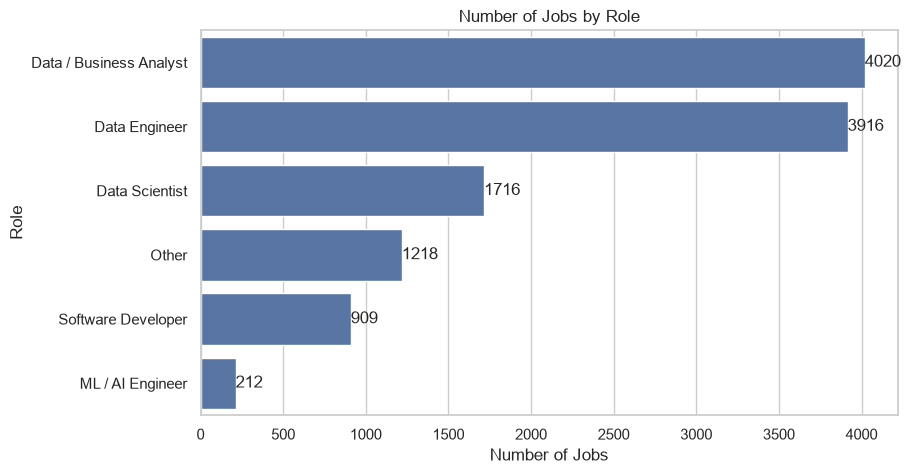

In [ ]:
plt.figure(figsize=(9, 5))
order = df['Role'].value_counts().index        # most common role first
ax = sns.countplot(data=df, y='Role', order=order)
ax.bar_label(ax.containers[0])
plt.title('Number of Jobs by Role')
plt.xlabel('Number of Jobs')
plt.ylabel('Role')
plt.show()

**Observation:** **Data / Business Analyst (4,020) and Data Engineer (3,916)** have the most openings, more than twice as many as Data Scientist (1,716). ML / AI Engineer jobs are few (212).

### Chart 4 — Jobs by Experience Level

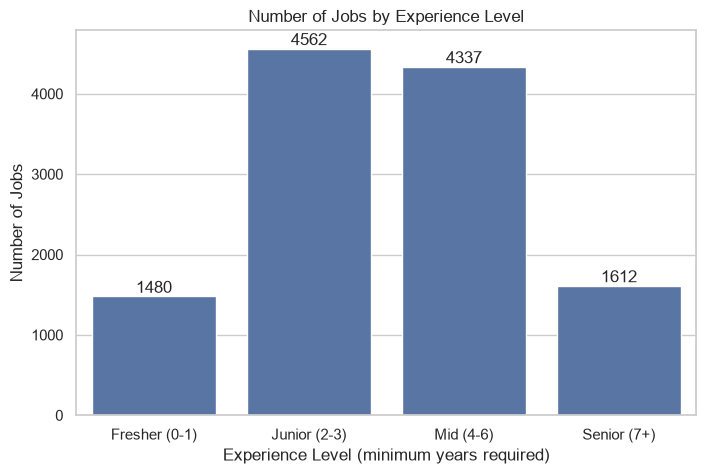

In [28]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Experience_Level')
ax.bar_label(ax.containers[0])
plt.title('Number of Jobs by Experience Level')
plt.xlabel('Experience Level (minimum years required)')
plt.ylabel('Number of Jobs')
plt.show()

**Observation:** Most jobs ask for 2 to 6 years of experience. **Only 1,480 jobs (about 12%) are open to freshers.**

### Chart 5 — Top 10 Skills for Fresher Jobs

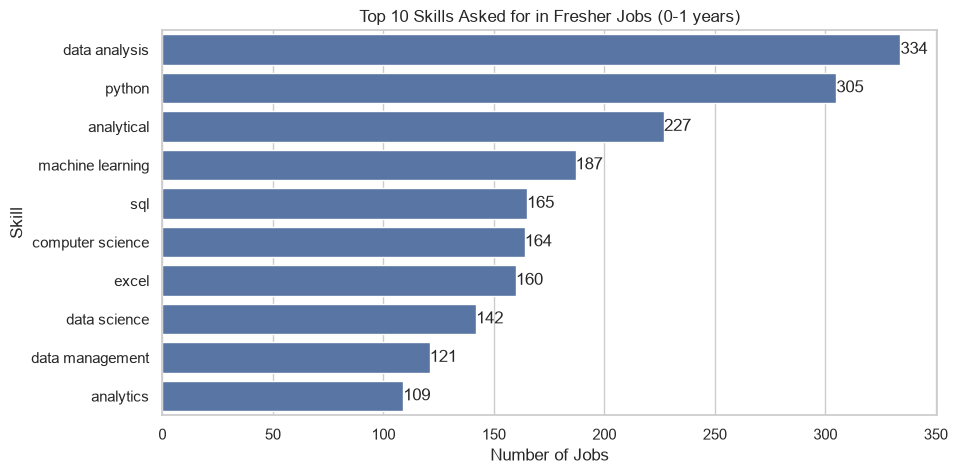

In [29]:
# Same skill count as Chart 2, but only for the filtered fresher jobs
fresher_skills = fresher_jobs['Skill_List'].explode().value_counts().head(10)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=fresher_skills.values, y=fresher_skills.index)
ax.bar_label(ax.containers[0])
plt.title('Top 10 Skills Asked for in Fresher Jobs (0-1 years)')
plt.xlabel('Number of Jobs')
plt.ylabel('Skill')
plt.show()

**Observation:** For fresher jobs, **data analysis (334) and Python (305)** are the top skills. **Excel (160)** appears here even though it is not in the overall top 15, so basic analysis tools matter more at entry level.

## Conclusion

In this experiment, raw job-posting data was turned into a clean, analysis-ready dataset. Wrong experience values and duplicates were removed, text was transformed into numbers and lists, different city spellings were merged, and new columns such as Role, Experience_Level and the skill flags were created. The data was then selected with loc[] / iloc[] and filtered with conditions, isin() and query().

These steps made better visualization possible: the city chart became correct only after cleaning, and charts such as top skills or jobs by experience level could not be drawn from the raw text at all. The results also give useful job-market insight: Python, data analysis and SQL are the key skills, Bengaluru, Hyderabad, Pune and Mumbai have the most openings, and fresher roles are mostly analyst jobs that also value Excel.